In [11]:
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
df = pd.read_csv("data/magangin_jobs_20260420_2310.csv")
df.head()

,source,title,link,location_raw,company_name,description_raw,skills,skills_count,role,location_city,region,jogja_tag,jabodetabek_tag,scraped_at,roadmap_url,is_tech,score
0,jobstreet,Junior Full Stack Engineer,https://id.jobstreet.com/id/job/91625021,Yogyakarta,18 ulasan,Lewati ke konten\nJobstreet\nCari lowongan\nCa...,"angular, css, django, flask, html, java, javas...",14,fullstack,yogyakarta,Yogyakarta,True,False,2026-04-20 23:02:18,https://roadmap.sh/full-stack,True,51
1,jobstreet,AI Engineer Internship,https://id.jobstreet.com/id/job/91578213,Tangerang,185 ulasan,Lewati ke konten\nJobstreet\nCari lowongan\nCa...,"cicd, css, excel, fastapi, git, javascript, ne...",13,ai/ml,tangerang,Jabodetabek,False,True,2026-04-20 23:00:46,https://roadmap.sh/ai-data-scientist,True,48
2,jobstreet,Junior Software Engineer (JAVA),https://id.jobstreet.com/id/job/91564329,Jakarta Raya,Selengkapnya tentang perusahaan ini⁠,Lewati ke konten\nJobstreet\nCari lowongan\nCa...,"agile, api, aws, azure, cicd, docker, gcp, git...",13,it-general,jakarta,Jabodetabek,False,True,2026-04-20 23:00:32,https://roadmap.sh/computer-science,True,45
3,jobstreet,Internship Programmer React+Python,https://id.jobstreet.com/id/job/91462870,Sleman,4 ulasan,Lewati ke konten\nJobstreet\nCari lowongan\nCa...,"django, flask, java, javascript, linux, php, p...",11,frontend,yogyakarta,Yogyakarta,True,False,2026-04-20 23:02:09,https://roadmap.sh/frontend,True,45
4,jobstreet,Programmer Intern,https://id.jobstreet.com/id/job/91515713,Jakarta Raya,28 ulasan,Lewati ke konten\nJobstreet\nCari lowongan\nCa...,"api, css, excel, express, git, html, java, jav...",11,it-general,jakarta,Jabodetabek,False,True,2026-04-20 23:02:42,https://roadmap.sh/computer-science,True,42


In [4]:
df.shape

(57, 17)

Setelah filter tech-only: 73 dari 108
Filter Jawa-only   : 57 lolos, 16 dibuang (luar Jawa/unknown)

=================================================================
TOTAL LOWONGAN UNIK  : 57

Distribusi Region:
  Jabodetabek               : 39
  Remote                    : 5
  Jawa Timur                : 5
  Yogyakarta                : 4
  Jawa Barat                : 4

Distribusi Role:
  it-general                : 20
  data                      : 18
  backend                   : 6
  fullstack                 : 4
  frontend                  : 3
  ai/ml                     : 2
  mobile                    : 1
  devops                    : 1
  cyber                     : 1
  qa                        : 1

--- TOP 10 LOWONGAN ---

  [51pts] Junior Full Stack Engineer
  Company  : 18 ulasan
  Role     : fullstack
  Skills   : angular, css, django, flask, html
  Location : yogyakarta → [Yogyakarta]
  Link     : https://id.jobstreet.com/id/job/91625021

  [48pts] AI Engineer Internship
  Company  : 185 ulasan
  Role     : ai/ml
  Skills   : cicd, css, excel, fastapi, git
  Location : tangerang → [Jabodetabek]
  Link     : https://id.jobstreet.com/id/job/91578213

  [45pts] Junior Software Engineer (JAVA)
  Company  : Selengkapnya tentang perusahaan ini⁠
  Role     : it-general
  Skills   : agile, api, aws, azure, cicd
  Location : jakarta → [Jabodetabek]
  Link     : https://id.jobstreet.com/id/job/91564329

  [45pts] Internship Programmer React+Python
  Company  : 4 ulasan
  Role     : frontend
  Skills   : django, flask, java, javascript, linux
  Location : yogyakarta → [Yogyakarta]
  Link     : https://id.jobstreet.com/id/job/91462870

  [42pts] Programmer Intern
  Company  : 28 ulasan
  Role     : it-general
  Skills   : api, css, excel, express, git
  Location : jakarta → [Jabodetabek]
  Link     : https://id.jobstreet.com/id/job/91515713

  [39pts] Software Engineer (Intern)
  Company  : N/A
  Role     : it-general
  Skills   : agile, api, css, git, html
  Location : jakarta → [Jabodetabek]
  Link     : https://glints.com/id/opportunities/jobs/software-engineer-intern/f3e22085-cdae-4839-a3ca-5ef2c00d5565

  [39pts] Data Engineer
  Company  : Selengkapnya tentang perusahaan ini⁠
  Role     : data
  Skills   : agile, aws, azure, cicd, excel
  Location : jakarta → [Jabodetabek]
  Link     : https://id.jobstreet.com/id/job/91276568

  [36pts] Backend Developer Intern
  Company  : N/A
  Role     : backend
  Skills   : django, fastapi, flask, html, java
  Location : jakarta → [Jabodetabek]
  Link     : https://glints.com/id/opportunities/jobs/backend-developer-intern/789346dd-12fc-4f84-8911-2c6a3d0da3ea

  [34pts] Fullstack Software Engineer
  Company  : Kinobi AI
  Role     : fullstack
  Skills   : cicd, excel, express, git, go
  Location : jakarta → [Remote]
  Link     : https://id.jobstreet.com/id/job/90967541

  [33pts] Data Analyst Intern
  Company  : Markethac
  Role     : data
  Skills   : aws, gcp, numpy, pandas, powerbi
  Location : jakarta → [Jabodetabek]
  Link     : https://glints.com/id/opportunities/jobs/data-analyst-intern/b73894b8-8331-4ed3-8063-51eec66a7781

✅ Saved → magangin_jobs_20260420_2310.csv  (57 lowongan)
(magangin) admin@macs magangin % 

In [5]:
df["role"].value_counts()
df["region"].value_counts()

region
Jabodetabek    39
Remote          5
Jawa Timur      5
Yogyakarta      4
Jawa Barat      4
Name: count, dtype: int64

In [6]:
from collections import Counter

skills = df["skills"].dropna().str.split(", ")
all_skills = [s for sublist in skills for s in sublist]

Counter(all_skills).most_common(10)

[('sql', 31),
 ('java', 27),
 ('javascript', 22),
 ('excel', 20),
 ('python', 16),
 ('git', 14),
 ('react', 12),
 ('css', 10),
 ('html', 10),
 ('php', 10)]

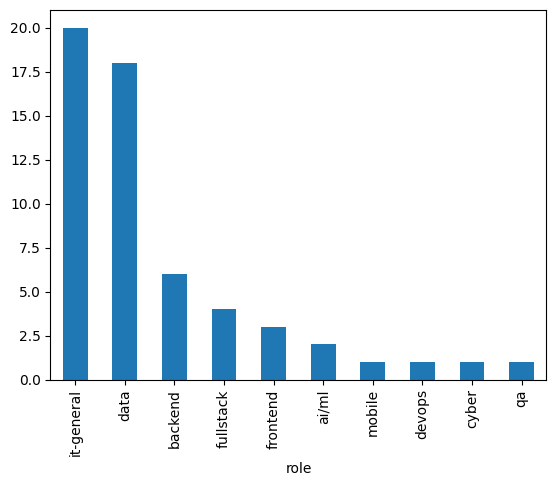

In [7]:
df["role"].value_counts().plot(kind="bar")
plt.show()


In [8]:
df.columns

Index(['source', 'title', 'link', 'location_raw', 'company_name',
       'description_raw', 'skills', 'skills_count', 'role', 'location_city',
       'region', 'jogja_tag', 'jabodetabek_tag', 'scraped_at', 'roadmap_url',
       'is_tech', 'score'],
      dtype='str')

In [ ]:
df_glob = pd.read_csv("data/job_dataset.csv")
df_glob.columns

Index(['JobID', 'Title', 'ExperienceLevel', 'YearsOfExperience', 'Skills',
       'Responsibilities', 'Keywords'],
      dtype='str')